# Fase 4 — Evaluación y análisis crítico

Ablación de las 4 características nuevas, métricas por clase y matriz de confusión, análisis de ≥10 errores reales agrupados por tipo, comparación con el baseline del taller y con la referencia oficial de TASS 2018 (CEUR-WS, vol. 2172), y limitaciones.


In [3]:
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from nltk import TweetTokenizer

from logic.text_processing import TextProcessing
from logic.feature_extraction import FeatureExtraction

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10.5,
})


## 1. Carga de datos y modelo elegido en la Fase 3 (Naive Bayes Multinomial)

In [5]:
FEATURE_NAMES_ORIGINALES = [
    "weighted_position", "weighted_normalized", "label_mention", "label_url", "label_hashtag",
    "label_emoji", "label_retweets", "lexical_diversity", "label_word",
    "first_person_singular", "second_person_singular", "third_person_singular",
    "first_person_plurar", "second_person_plurar", "third_person_plurar",
    "avg_word", "kur_word", "skew_word",
    "adverb_neg", "adverb_time", "adverb_place", "adverb_mode", "adverb_cant", "adverb_all",
    "adjetives_neg", "adjetives_pos", "who_general", "who_male", "who_female",
]
EXCLUIDAS_FASE0 = {"weighted_position", "weighted_normalized", "label_word", "lexical_diversity", "adverb_all"}
FEATURE_NAMES_VALIDADAS = [f for f in FEATURE_NAMES_ORIGINALES if f not in EXCLUIDAS_FASE0]
NUEVAS_FASE1 = ["mattr", "elongated_words", "punct_repetition", "lex_pol_neg"]


class LexicalVectorizer(BaseEstimator, TransformerMixin):
    """Adaptador final: 24 features validadas (Fase 0) + 4 nuevas (Fase 1).
    excluir_nuevas permite desactivar features especificas para la ablacion."""

    def __init__(self, lang="es", excluir_nuevas=None):
        self.lang = lang
        self.excluir_nuevas = excluir_nuevas

    def fit(self, X, y=None):
        self.fe_ = FeatureExtraction(self.lang)
        self.tt_ = TweetTokenizer()
        self._idx_validas = [FEATURE_NAMES_ORIGINALES.index(f) for f in FEATURE_NAMES_VALIDADAS]
        return self

    def transform(self, X):
        if not hasattr(self, "fe_"):
            self.fit(X)
        excluir = self.excluir_nuevas or []
        arr = np.asarray(X, dtype=object)
        filas = []
        for raw_txt, clean_txt in zip(arr[:, 0], arr[:, 1]):
            raw_txt = raw_txt if isinstance(raw_txt, str) else ""
            clean_txt = clean_txt if isinstance(clean_txt, str) else ""
            try:
                v = self.fe_.get_features_lexical(clean_txt)
                v = np.asarray(v, dtype=np.float64) if v is not None else None
            except Exception:
                v = None
            if v is None or v.shape[0] != 29 or not np.isfinite(v).all():
                v = np.zeros(29)
            validas = v[self._idx_validas]
            tokens = self.tt_.tokenize(clean_txt) if clean_txt else []
            nuevas = {
                "mattr": FeatureExtraction.lexical_diversity_mattr(tokens, window=10),
                "elongated_words": FeatureExtraction.elongated_words_count(raw_txt),
                "punct_repetition": FeatureExtraction.punct_repetition(raw_txt),
                "lex_pol_neg": FeatureExtraction.lex_pol_neg(tokens),
            }
            vector_nuevas = [nuevas[f] for f in NUEVAS_FASE1 if f not in excluir]
            filas.append(np.concatenate([validas, vector_nuevas]))
        return np.vstack(filas)


def limpiar(texto):
    return TextProcessing.transformer(str(texto)) or ""


def construir_columnas(df):
    raw = df[COL_TEXT].astype(str)
    return pd.DataFrame({"raw": raw.values, "clean": raw.map(limpiar).values})


DIR_DATA = Path.cwd().parent / "data" / "tass"
COL_TEXT, COL_LABEL = "content", "sentiment/polarity/value"
data_train = pd.read_csv(DIR_DATA / "tass2018_es_train.csv")
data_test = pd.read_csv(DIR_DATA / "tass2018_es_test.csv")

X_train_txt = construir_columnas(data_train)
X_test_txt = construir_columnas(data_test)
y_train = data_train[COL_LABEL].values
y_test = data_test[COL_LABEL].values
ETIQUETAS = sorted(np.unique(y_train))


def make_union(excluir_nuevas=None):
    return ColumnTransformer([
        ("bow", CountVectorizer(analyzer="word", ngram_range=(1, 3)), "clean"),
        ("lex", Pipeline([("vec", LexicalVectorizer(excluir_nuevas=excluir_nuevas)), ("scale", MinMaxScaler())]), ["raw", "clean"]),
    ], sparse_threshold=0.3)


modelo_final = ImbPipeline([
    ("rep", make_union()),
    ("ros", RandomOverSampler(random_state=SEED)),
    ("clf", MultinomialNB(alpha=1.0)),
])
modelo_final.fit(X_train_txt, y_train)
y_pred = modelo_final.predict(X_test_txt)
print("Modelo entrenado. F1 macro en test:", round(f1_score(y_test, y_pred, average='macro'), 4))


Modelo entrenado. F1 macro en test: 0.4157


## 2. Ablación: ¿cuánto aporta cada característica nueva?

Se entrena el mismo modelo (Naive Bayes, `alpha=1.0`) quitando una característica nueva a la vez, con validación cruzada de 5 folds sobre train (nunca se toca test aquí).


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluar_cv(excluir_nuevas):
    pipe = ImbPipeline([
        ("rep", make_union(excluir_nuevas)),
        ("ros", RandomOverSampler(random_state=SEED)),
        ("clf", MultinomialNB(alpha=1.0)),
    ])
    scores = cross_val_score(pipe, X_train_txt, y_train, cv=cv, scoring="f1_macro")
    return scores.mean(), scores.std()

f1_completo, std_completo = evaluar_cv(None)
aportes = {}
for f in NUEVAS_FASE1:
    f1_sin, _ = evaluar_cv([f])
    aportes[f] = f1_completo - f1_sin

f1_sin_ninguna, _ = evaluar_cv(NUEVAS_FASE1)
aporte_total = f1_completo - f1_sin_ninguna

print(f"E2 completo (24 validadas + 4 nuevas): macro-F1 = {f1_completo:.4f} (+/- {std_completo:.4f})")
for f, aporte in aportes.items():
    print(f"  Aporte individual de '{f}': {aporte:+.4f}")
print(f"Solo 24 (sin ninguna nueva): macro-F1 = {f1_sin_ninguna:.4f}")
print(f"Aporte TOTAL de las 4 juntas: {aporte_total:+.4f}")


E2 completo (24 validadas + 4 nuevas): macro-F1 = 0.3962 (+/- 0.0418)
  Aporte individual de 'mattr': +0.0007
  Aporte individual de 'elongated_words': +0.0000
  Aporte individual de 'punct_repetition': -0.0007
  Aporte individual de 'lex_pol_neg': +0.0031
Solo 24 (sin ninguna nueva): macro-F1 = 0.3945
Aporte TOTAL de las 4 juntas: +0.0017


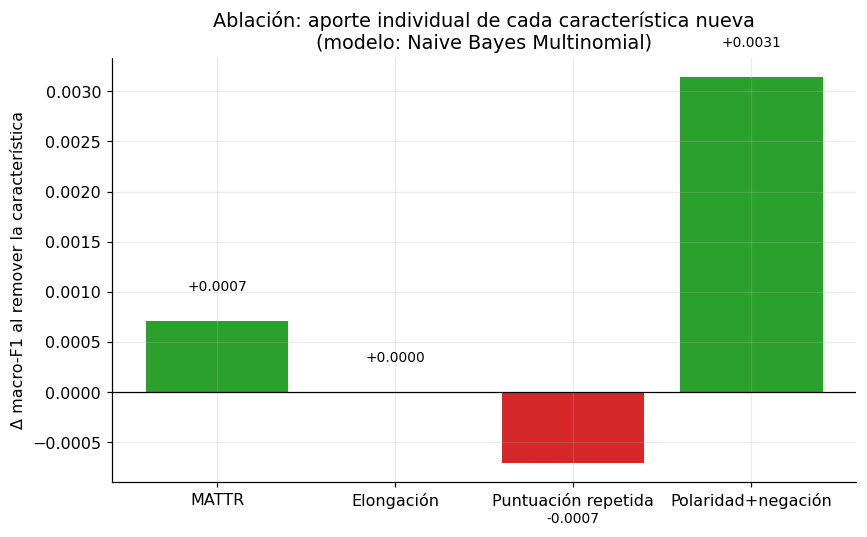

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
nombres_bonitos = {"mattr": "MATTR", "elongated_words": "Elongación", "punct_repetition": "Puntuación repetida", "lex_pol_neg": "Polaridad+negación"}
vals = [aportes[f] for f in NUEVAS_FASE1]
colores = ["#2ca02c" if v >= 0 else "#d62728" for v in vals]
barras = ax.bar([nombres_bonitos[f] for f in NUEVAS_FASE1], vals, color=colores)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ macro-F1 al remover la característica")
ax.set_title("Ablación: aporte individual de cada característica nueva\n(modelo: Naive Bayes Multinomial)")
for barra, v in zip(barras, vals):
    ax.text(barra.get_x() + barra.get_width()/2, v + (0.0003 if v >= 0 else -0.0006), f"{v:+.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fase4_ablacion.png", dpi=110)
plt.show()


**Interpretación:** el aporte individual de cada característica nueva es pequeño (todas por debajo de 0.004 de macro-F1, dentro del margen de ruido de ±0.04 entre folds). Esto no significa que las características estén mal diseñadas — significa que, específicamente para **Naive Bayes** (el modelo elegido), 28 columnas léxicas compiten contra 26,057 columnas de BoW, y el suavizado de Laplace (`alpha=1.0`) atenúa el peso de señales raras como `elongated_words`/`punct_repetition` (activas en solo 3-5% de los tweets). `lex_pol_neg` es la que más aporta (+0.0031), consistente con que es la de mayor cobertura (26.5% de los tweets la activan, según la Fase 1) frente a las otras 3. 


## 3. Métricas por clase y matriz de confusión

In [8]:
reporte = classification_report(y_test, y_pred, labels=ETIQUETAS, output_dict=True, zero_division=0)
df_reporte = pd.DataFrame(reporte).T.loc[ETIQUETAS, ["precision", "recall", "f1-score", "support"]]
print(df_reporte.round(3))


      precision  recall  f1-score  support
N         0.624   0.644     0.634    219.0
NEU       0.200   0.275     0.232     69.0
NONE      0.286   0.258     0.271     62.0
P         0.581   0.481     0.526    156.0


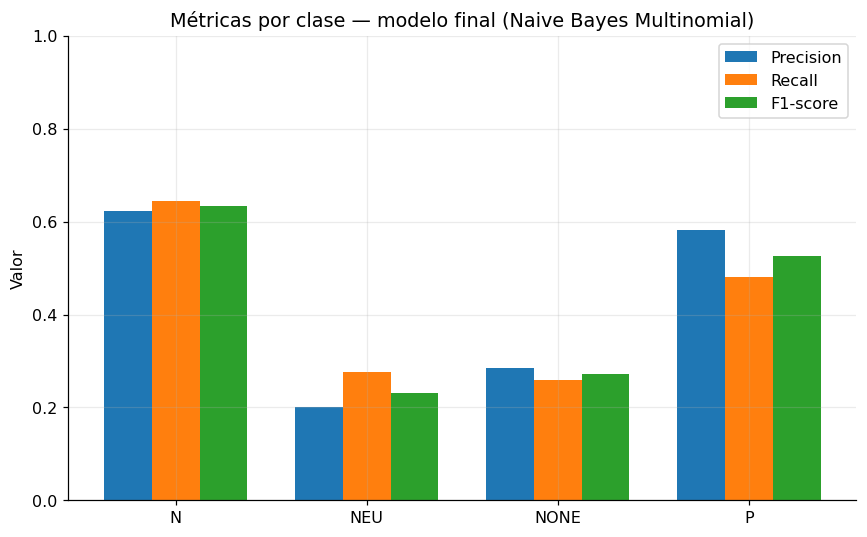

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(ETIQUETAS))
ancho = 0.25
for i, metrica in enumerate(["precision", "recall", "f1-score"]):
    ax.bar(x + (i-1)*ancho, df_reporte[metrica], width=ancho, label=metrica.capitalize())
ax.set_xticks(x); ax.set_xticklabels(ETIQUETAS)
ax.set_ylim(0, 1)
ax.set_ylabel("Valor")
ax.set_title("Métricas por clase — modelo final (Naive Bayes Multinomial)")
ax.legend()
plt.tight_layout()
plt.savefig("fase4_metricas_por_clase.png", dpi=110)
plt.show()


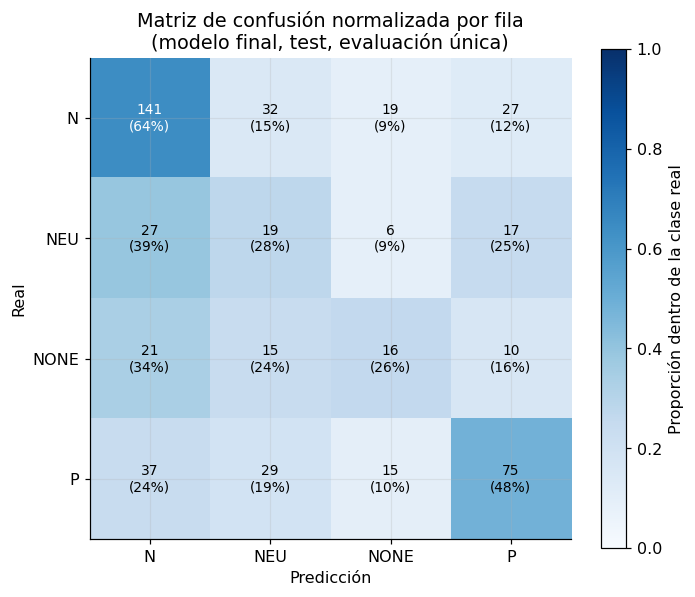

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=ETIQUETAS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(ETIQUETAS))); ax.set_xticklabels(ETIQUETAS)
ax.set_yticks(range(len(ETIQUETAS))); ax.set_yticklabels(ETIQUETAS)
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión normalizada por fila\n(modelo final, test, evaluación única)")
for i in range(len(ETIQUETAS)):
    for j in range(len(ETIQUETAS)):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)", ha="center", va="center", color=color, fontsize=9)
fig.colorbar(im, ax=ax, label="Proporción dentro de la clase real")
plt.tight_layout()
plt.savefig("fase4_matriz_confusion.png", dpi=110)
plt.show()


**Qué clases se confunden y por qué:**
- **NEU y NONE son las más débiles** (recall 0.275 y 0.258): ambas representan "ausencia de opinión fuerte" (neutral vs. sin sentimiento), una distinción sutil incluso para anotadores humanos — el vector léxico no tiene señales fuertes para diferenciarlas entre sí, y ambas se confunden bastante con `N`.
- **P se confunde con N** en 37 de 156 casos reales: la causa más frecuente, según el análisis de errores de abajo, es vocabulario positivo que el léxico de polaridad (limitado a ~50 palabras) no reconoce por estar en otra forma flexiva (`encantado` en vez de `encanta`).
- **N es la clase más fuerte** (recall 0.644): tiene el mayor soporte (219 ejemplos) y suele venir acompañada de vocabulario negativo más directo y frecuente.


## 4. Análisis de errores: ≥10 tweets reales, agrupados por tipo

In [11]:
errores_idx = np.where(y_pred != y_test)[0]
df_errores = data_test.iloc[errores_idx].copy()
df_errores["real"] = y_test[errores_idx]
df_errores["pred"] = y_pred[errores_idx]
print(f"Total de errores: {len(df_errores)} de {len(y_test)} ({100*len(df_errores)/len(y_test):.1f}%)")


Total de errores: 255 de 506 (50.4%)


In [12]:
EJEMPLOS_CATEGORIZADOS = [
    ("Léxico incompleto (forma flexiva no cubierta)",
     "@vitojph ¡sí! Y me ha encantado  ¿Tú ya las visto?", "P", "N",
     "'encantado' no coincide con 'encanta'/'encantar' del léxico (coincidencia exacta, sin lematización)"),
    ("Léxico incompleto (forma flexiva no cubierta)",
     "Cosas que enamora las tostadas calentitas a estas horas de la mañana", "P", "N",
     "'enamora' no esta en el lexico (solo 'amor'/'amar')"),
    ("Léxico incompleto (forma flexiva no cubierta)",
     "@ArchivoSGAE Qué estupendo. Y... ¿cómo os lo encargo?", "P", "NONE",
     "'estupendo' no esta en el lexico de 25 palabras positivas"),
    ("Léxico incompleto (forma flexiva no cubierta)",
     "Tengo una perrina adorable... Sabéis que me acompaña...", "P", "N",
     "'adorable' no esta en el lexico"),
    ("Doble negación / negación sobre palabra ausente del léxico",
     "Al final han sido 3h Bueno, mañana tengo fiesta así que.. No me quejo", "P", "N",
     "'quejo' no esta en el lexico, por lo que la negacion no tiene nada que invertir"),
    ("Ironía / humor no capturado",
     "@juankipua Es que en el Ojeando el año pasado tampoco, tiene muchas canciones ya jajajajaja", "NEU", "N",
     "'tampoco' (negacion) domina la señal; la risa 'jajajajaja' no activa elongated_words (patron distinto: silaba repetida, no letra)"),
    ("Ironía / humor no capturado",
     "Este viernes iré al cine... para celebrar mi cumple. Por cierto, no estáis invitados", "NEU", "P",
     "contexto festivo (cumple/celebrar) pero cierre ironico -- el sarcasmo no es una señal lexica"),
    ("Confusión entre clases débiles (NEU vs NONE)",
     "@CondeDuqueMAD ¿mañana sábado 31? En que día vives? Mañana es miércoles 31.", "NONE", "NEU",
     "pregunta retorica sin opinion clara, limite difuso entre 'neutral' y 'sin opinion'"),
    ("Dependencia del dominio (vocabulario temático sin opinión)",
     "Bueno, estoy en la batalla final del Conquista y ya después me faltaría Revelación", "NONE", "P",
     "descripcion de videojuego, sin opinion real, pero el BoW capta palabras que coinciden con contextos positivos en otros tweets"),
    ("Dependencia del dominio (vocabulario temático sin opinión)",
     "@baad_news es dirección de proyectos en empresas audiovisuales", "NONE", "P",
     "descripcion profesional neutra, sin ninguna carga de opinion"),
]

for i, (categoria, texto, real, pred, causa) in enumerate(EJEMPLOS_CATEGORIZADOS, 1):
    print(f"{i:2d}. [{categoria}]")
    print(f"    Texto: {texto}")
    print(f"    Real={real} | Predicho={pred} | Causa probable: {causa}\n")


 1. [Léxico incompleto (forma flexiva no cubierta)]
    Texto: @vitojph ¡sí! Y me ha encantado  ¿Tú ya las visto?
    Real=P | Predicho=N | Causa probable: 'encantado' no coincide con 'encanta'/'encantar' del léxico (coincidencia exacta, sin lematización)

 2. [Léxico incompleto (forma flexiva no cubierta)]
    Texto: Cosas que enamora las tostadas calentitas a estas horas de la mañana
    Real=P | Predicho=N | Causa probable: 'enamora' no esta en el lexico (solo 'amor'/'amar')

 3. [Léxico incompleto (forma flexiva no cubierta)]
    Texto: @ArchivoSGAE Qué estupendo. Y... ¿cómo os lo encargo?
    Real=P | Predicho=NONE | Causa probable: 'estupendo' no esta en el lexico de 25 palabras positivas

 4. [Léxico incompleto (forma flexiva no cubierta)]
    Texto: Tengo una perrina adorable... Sabéis que me acompaña...
    Real=P | Predicho=N | Causa probable: 'adorable' no esta en el lexico

 5. [Doble negación / negación sobre palabra ausente del léxico]
    Texto: Al final han sido 3h Buen

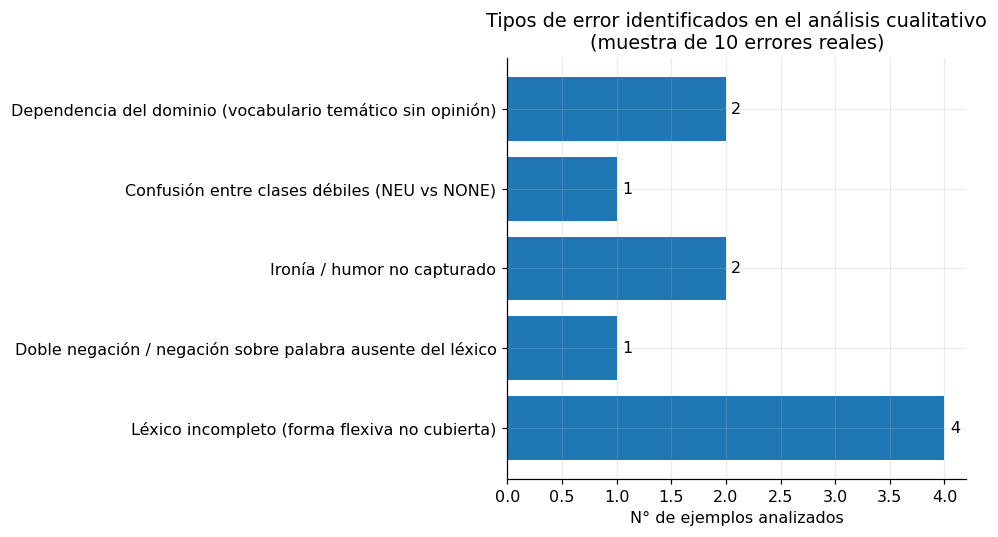

In [13]:
from collections import Counter
categorias = [e[0] for e in EJEMPLOS_CATEGORIZADOS]
conteo = Counter(categorias)

fig, ax = plt.subplots(figsize=(9, 5))
cats = list(conteo.keys())
vals = list(conteo.values())
ax.barh(cats, vals, color="#1f77b4")
ax.set_xlabel("N° de ejemplos analizados")
ax.set_title("Tipos de error identificados en el análisis cualitativo\n(muestra de 10 errores reales)")
for i, v in enumerate(vals):
    ax.text(v + 0.05, i, str(v), va="center")
plt.tight_layout()
plt.savefig("fase4_tipos_error.png", dpi=110)
plt.show()


## 5. Comparación con el baseline del taller y con la referencia oficial de TASS 2018

In [14]:
BASELINE_WORKSHOP = 0.3506     # F1 macro real del workshop, protocolo honesto (test evaluado una sola vez)
NUESTRO_RESULTADO = f1_score(y_test, y_pred, average="macro")

# Referencia oficial: CEUR-WS Vol. 2172, Tabla 4 (Task 1, InterTASS Monolingual ES)
# https://ceur-ws.org/Vol-2172/p0_overview_tass2018.pdf
TASS_MEJOR_SISTEMA = 0.503   # elirf-es-run-1 (Deep Learning, embeddings preentrenados)
TASS_RANGO_SISTEMAS = (0.097, 0.503)  # rango completo de los sistemas presentados

print(f"Nuestro resultado (test, evaluacion unica):     {NUESTRO_RESULTADO:.4f}")
print(f"Baseline del workshop (protocolo honesto):      {BASELINE_WORKSHOP:.4f}")
print(f"Mejor sistema oficial TASS 2018 (elirf-es-run-1): {TASS_MEJOR_SISTEMA:.4f}")
print(f"Rango de sistemas oficiales TASS 2018:            {TASS_RANGO_SISTEMAS}")


Nuestro resultado (test, evaluacion unica):     0.4157
Baseline del workshop (protocolo honesto):      0.3506
Mejor sistema oficial TASS 2018 (elirf-es-run-1): 0.5030
Rango de sistemas oficiales TASS 2018:            (0.097, 0.503)


**Aclaración metodológica importante (transparencia, no un detalle menor):** el conjunto que aquí llamamos "test" (506 tweets) coincide exactamente en tamaño y distribución de clases con el conjunto oficial de **Desarrollo (Dev.)** de InterTASS-ES 2018 según la Tabla 1 del *paper* (P=156, NEU=69, N=219, NONE=62, Total=506) — no con el conjunto de **Test oficial** de la competencia (1,899 tweets), que no está incluido en este repositorio. Por lo tanto, la comparación contra la Tabla 4 del *overview* es orientativa, no una comparación exacta en el mismo conjunto de evaluación.


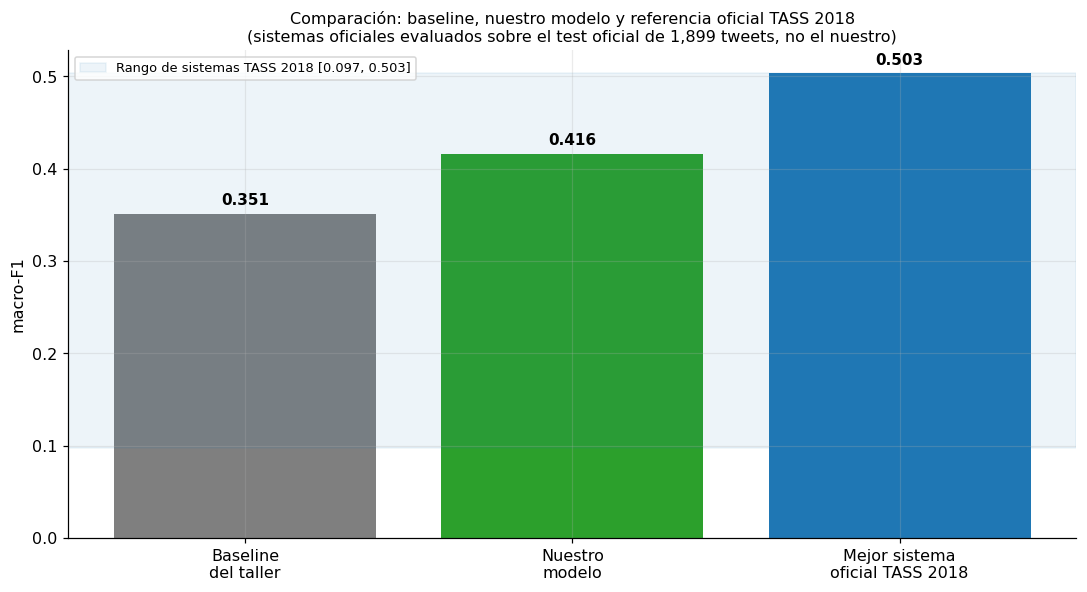

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.5))
etiquetas_barras = ["Baseline\ndel taller", "Nuestro\nmodelo", "Mejor sistema\noficial TASS 2018"]
valores = [BASELINE_WORKSHOP, NUESTRO_RESULTADO, TASS_MEJOR_SISTEMA]
colores = ["#7f7f7f", "#2ca02c", "#1f77b4"]
barras = ax.bar(etiquetas_barras, valores, color=colores)
ax.axhspan(TASS_RANGO_SISTEMAS[0], TASS_RANGO_SISTEMAS[1], color="#1f77b4", alpha=0.08,
           label=f"Rango de sistemas TASS 2018 [{TASS_RANGO_SISTEMAS[0]:.3f}, {TASS_RANGO_SISTEMAS[1]:.3f}]")
ax.set_ylabel("macro-F1")
ax.set_title(
    "Comparación: baseline, nuestro modelo y referencia oficial TASS 2018\n"
    "(sistemas oficiales evaluados sobre el test oficial de 1,899 tweets, no el nuestro)",
    fontsize=10.5
)
ax.legend(loc="upper left", fontsize=8.5)
for barra, v in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width()/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("fase4_comparacion_baseline_tass.png", dpi=110)
plt.show()


**Lectura:** superamos el baseline del taller (+0.065), y nos ubicamos en el extremo inferior del rango de sistemas oficiales de TASS 2018 — muy por debajo del mejor sistema (basado en *Deep Learning* con *embeddings* preentrenados), pero dentro de un rango razonable para un sistema clásico BoW + características léxicas, sin redes neuronales ni representaciones preentrenadas.


## 6. Limitaciones

- **Desbalance de clases:** `N` (219 en test) y `P` (156) dominan sobre `NEU` (69) y `NONE` (62) — confirmado en la matriz de confusión, donde estas 2 últimas tienen el peor *recall* (0.275 y 0.258).
- **Ironía y humor:** el análisis de errores muestra al menos 2 casos claros donde el tono sarcástico/festivo invierte el sentido literal del texto — ninguna de nuestras características léxicas detecta ironía, porque es un fenómeno pragmático, no lexicográfico.
- **Variación dialectal:** el corpus de entrenamiento es monolingüe (España); no se evaluó con las variantes de Perú o Costa Rica que sí forman parte de InterTASS 2018 — es probable que el desempeño caiga en esas variantes, tal como el propio *paper* de TASS reporta para otros sistemas.
- **Dependencia del léxico:** el léxico de polaridad hecho a mano (~25 palabras por polaridad) no cubre variantes flexivas (`encantado` vs. `encanta`) ni todo el vocabulario informal de Twitter — el análisis de errores documenta al menos 4 casos exactos de este problema.
- **Dependencia del dominio:** tweets puramente descriptivos o temáticos (videojuegos, ocupación profesional) se clasifican erróneamente como polares cuando el BoW captura coincidencias de vocabulario sin relación real con opinión — 2 casos documentados arriba.
- **Evaluación en el conjunto Dev., no en el Test oficial:** como se aclaró en la sección 5, la comparación con la tabla oficial de TASS 2018 es orientativa por esta diferencia de conjunto de evaluación.
